Create connection to database and fill dataframe

In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

DB_PATH = r"database/train.sqlite"

conn = sqlite3.connect(DB_PATH)
df = pd.read_sql("Select * from tripdata limit 5000000", conn)

First Checks

In [8]:
df.head()

,vendorid,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,ratecodeid,store_and_fwd_flag,pulocationid,dolocationid,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1.0,2019-01-05 09:13:49.000000,2019-01-05 09:21:41.000000,1.0,1.70,1.0,N,61.0,17.0,2.0,8.0,0.0,0.5,0.00,0.0,0.3,8.80,NaN
1,2.0,2019-01-04 18:27:56.000000,2019-01-04 18:44:52.000000,1.0,2.20,1.0,N,234.0,231.0,1.0,12.0,1.0,0.5,1.50,0.0,0.3,15.30,NaN
2,2.0,2019-01-03 13:23:07.000000,2019-01-03 13:28:44.000000,1.0,1.07,1.0,N,170.0,107.0,1.0,6.0,0.0,0.5,1.36,0.0,0.3,8.16,NaN
3,1.0,2019-01-02 23:02:29.000000,2019-01-02 23:17:56.000000,1.0,8.20,1.0,N,261.0,263.0,1.0,24.5,0.5,0.5,5.15,0.0,0.3,30.95,NaN
4,2.0,2019-01-04 19:14:43.000000,2019-01-04 19:26:42.000000,1.0,2.76,1.0,N,262.0,41.0,1.0,11.0,1.0,0.5,2.56,0.0,0.3,15.36,NaN


In [9]:
print(df.describe())

            vendorid  passenger_count  trip_distance     ratecodeid  \
count  500000.000000    500000.000000  500000.000000  500000.000000   
mean        1.645754         1.617026       2.886468       1.049052   
std         0.547361         1.253665       3.551863       0.551538   
min         1.000000         0.000000       0.010000       1.000000   
25%         1.000000         1.000000       0.970000       1.000000   
50%         2.000000         1.000000       1.600000       1.000000   
75%         2.000000         2.000000       3.000000       1.000000   
max         4.000000         8.000000      20.000000      99.000000   

        pulocationid   dolocationid   payment_type    fare_amount  \
count  500000.000000  500000.000000  500000.000000  500000.000000   
mean      162.984296     160.929906       1.353202      12.058614   
std        66.997829      71.096592       0.496011      13.944560   
min         1.000000       1.000000       1.000000     -56.770000   
25%       114.0

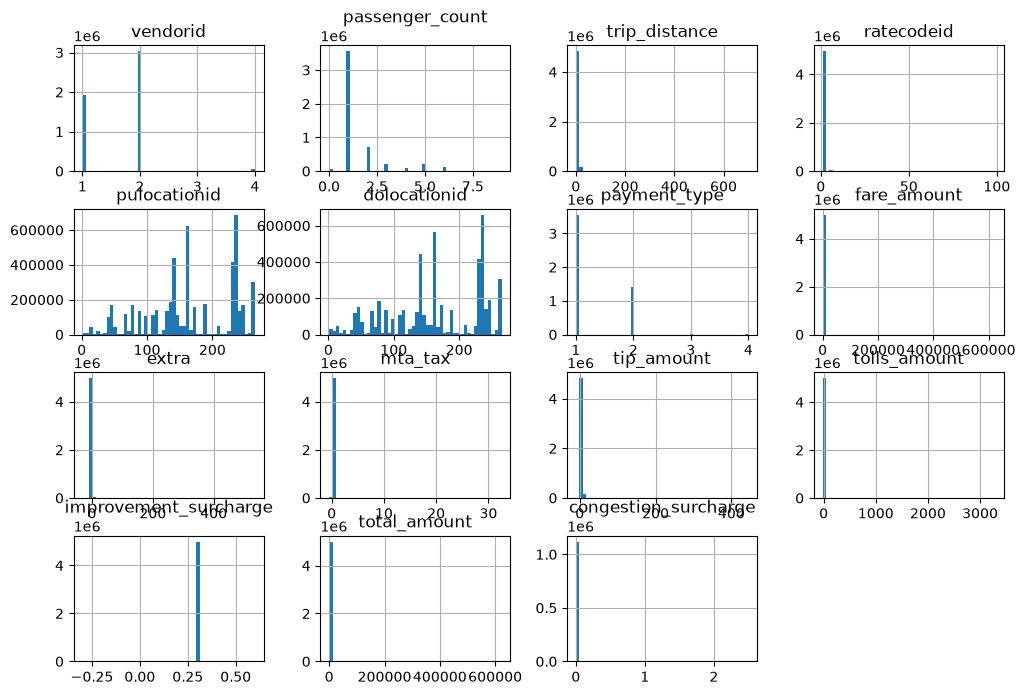

In [4]:
df.hist(bins=50,
figsize=(12, 8))
plt.show()

^ Many histogramms being dominated by outliers

<Axes: >

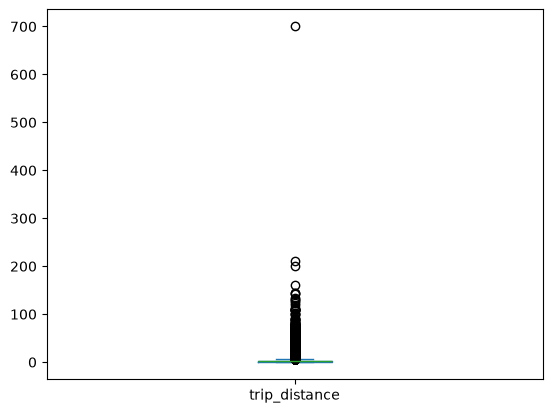

In [5]:
df.plot.box(column='trip_distance')

Limiting down to a more realistic value, to get a better overview

In [6]:
df = pd.read_sql("Select * from tripdata where trip_distance between 0.01 and 20  limit 500000", conn)

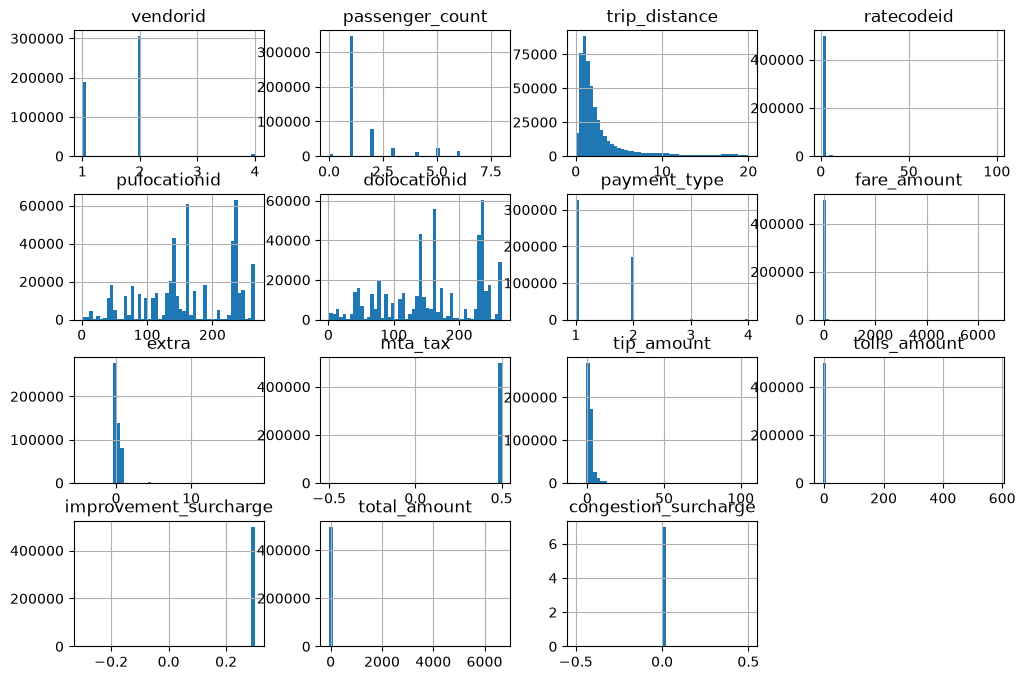

In [10]:
df.hist(bins=50,
figsize=(12, 8))
plt.show()

^ Now trip_distance has visual bars

<Axes: >

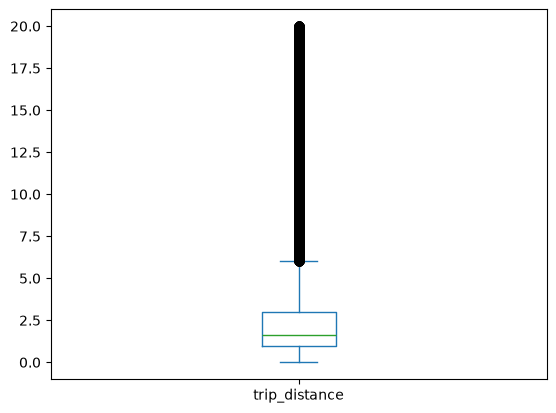

In [7]:
df.plot.box(column='trip_distance')

First scatter plot, getting duration in mins by using both timestamps and filtering out the incredibly high duration times

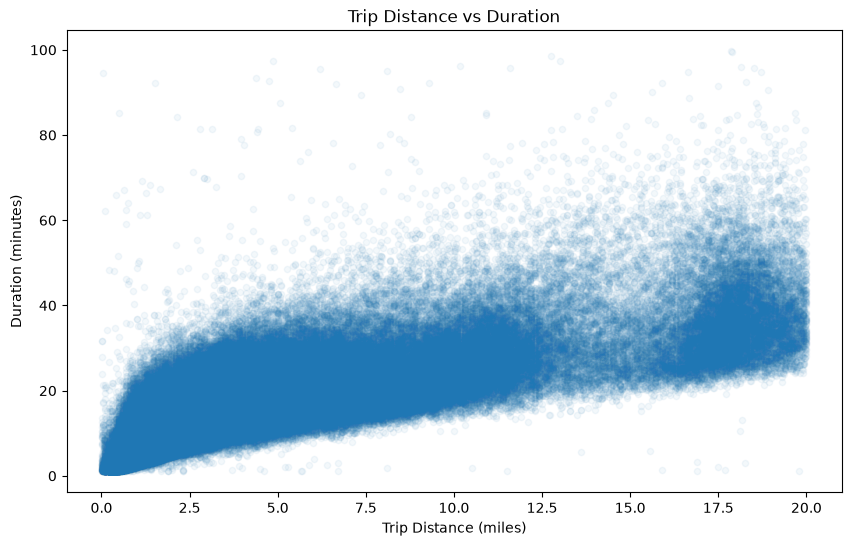

In [17]:
df['duration_min'] = (pd.to_datetime(df['tpep_dropoff_datetime']) - pd.to_datetime(df['tpep_pickup_datetime'])).dt.total_seconds() / 60

df_plot = df[(df['duration_min'] > 1) & (df['duration_min'] < 100)]

df_plot.plot(kind='scatter', x='trip_distance', y='duration_min', alpha=0.05, figsize=(10, 6))
plt.title('Trip Distance vs Duration')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Duration (minutes)')
plt.show()

^ Obvious correlation between increased trip distance and duration

In [21]:
cols = ['trip_distance', 'duration_min', 'passenger_count', 'ratecodeid', 'pulocationid', 'dolocationid']
df_plot[cols].corr()

,trip_distance,duration_min,passenger_count,ratecodeid,pulocationid,dolocationid
trip_distance,1.000000,0.819145,0.015918,0.258139,-0.095045,-0.108908
duration_min,0.819145,1.000000,0.015065,0.194954,-0.078280,-0.106169
passenger_count,0.015918,0.015065,1.000000,-0.008177,-0.007828,-0.005834
ratecodeid,0.258139,0.194954,-0.008177,1.000000,-0.023487,-0.023167
pulocationid,-0.095045,-0.078280,-0.007828,-0.023487,1.000000,0.114928
dolocationid,-0.108908,-0.106169,-0.005834,-0.023167,0.114928,1.000000


In [31]:
cols = ['duration_min', 'trip_distance', 'passenger_count', 'ratecodeid', 'pulocationid', 'dolocationid']
px.imshow( df_plot[cols].corr() )

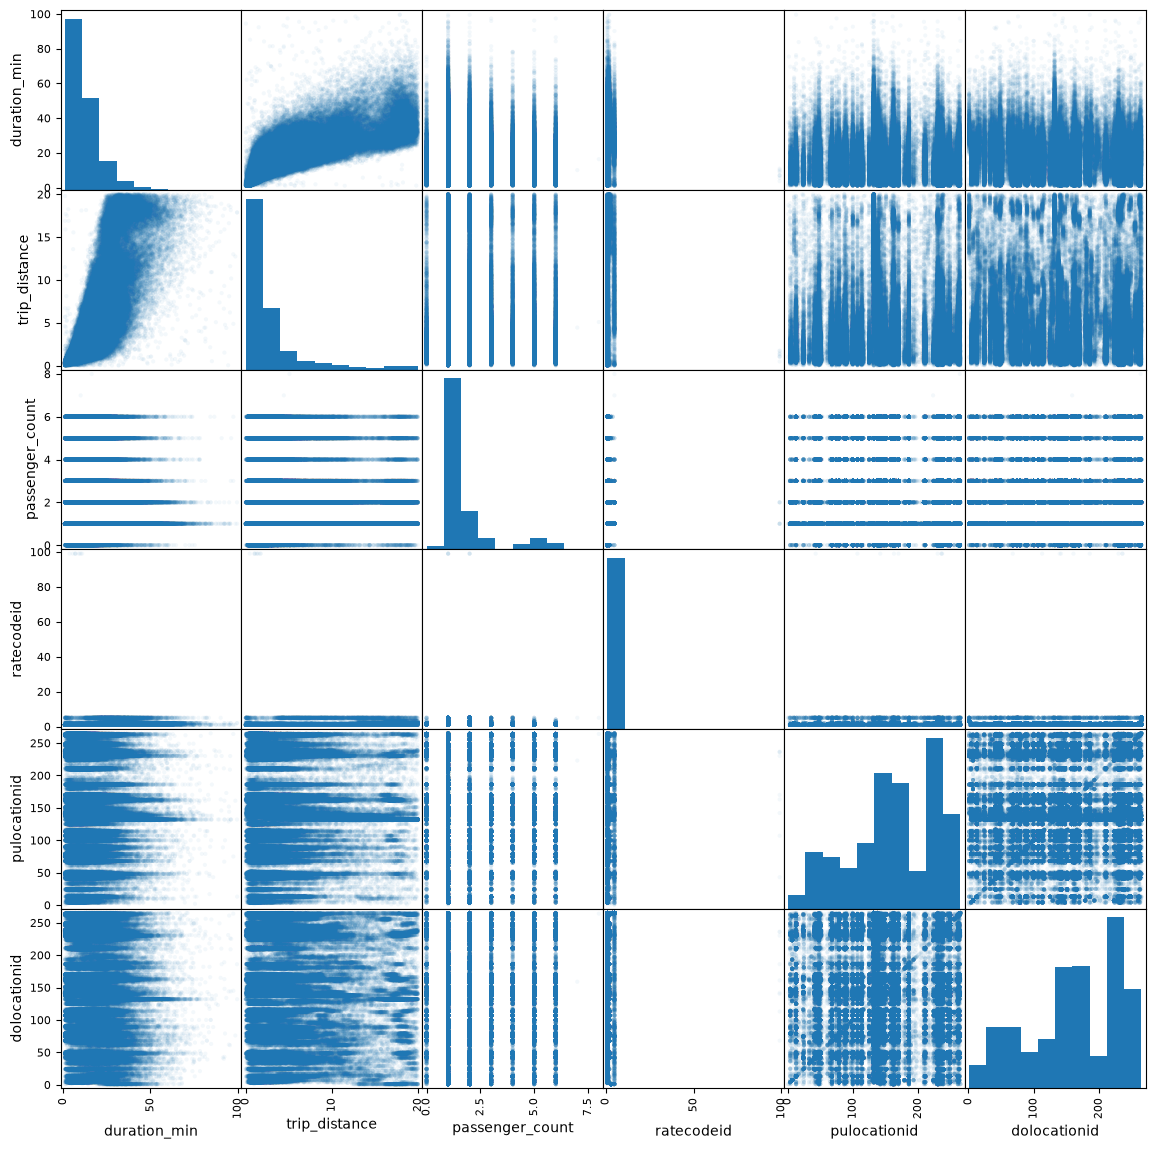

In [32]:
pd.plotting.scatter_matrix(df_plot[cols], alpha=0.05, figsize=(14, 14), diagonal='hist')
plt.show()

Maybe limit things more to make it seem more visible?

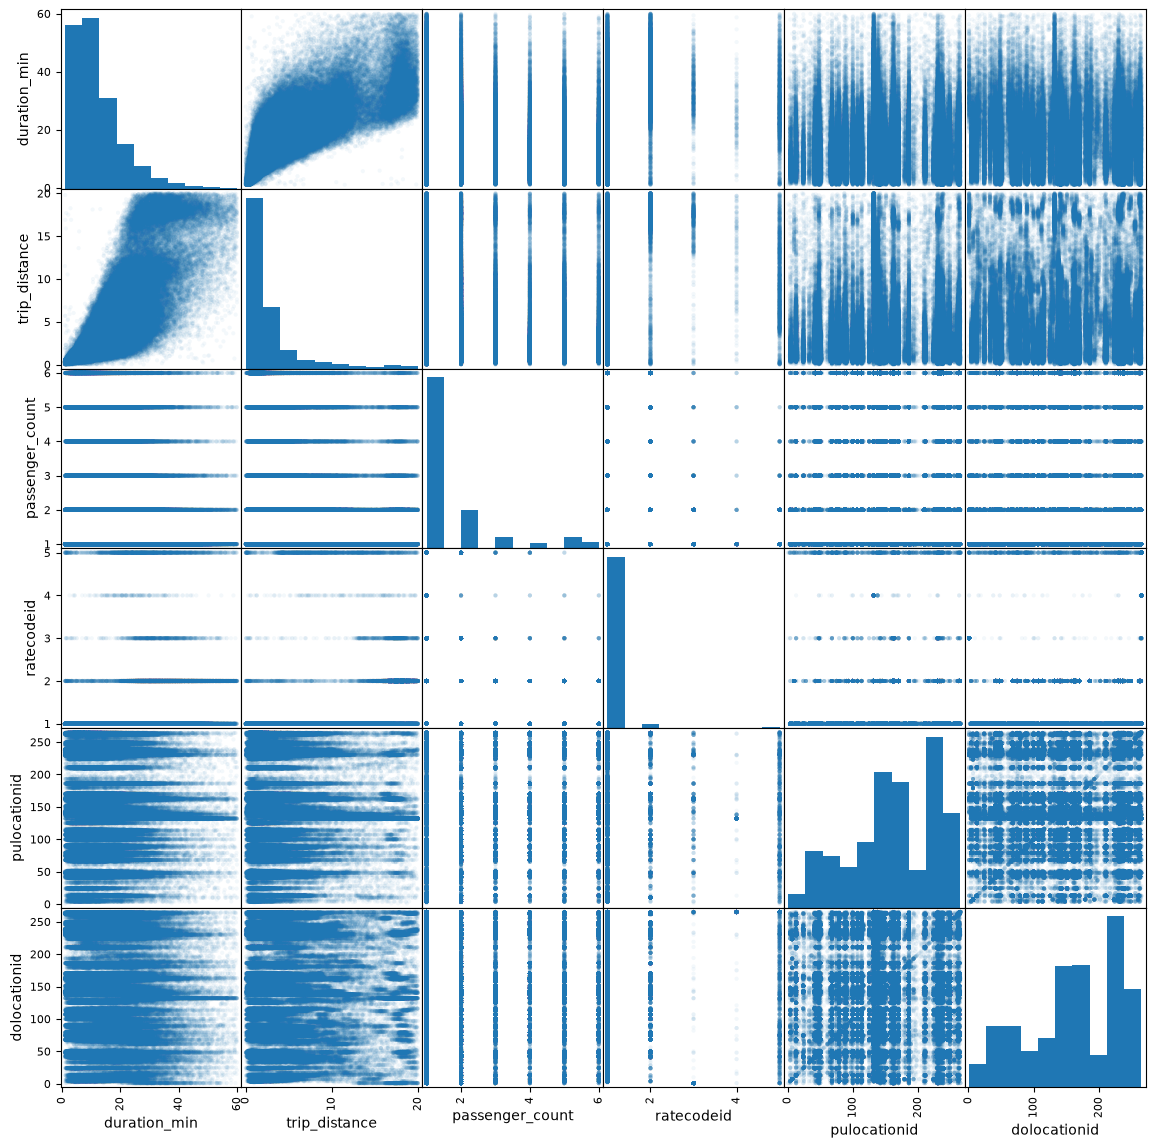

In [33]:
df_clean = df_plot[
    (df_plot['duration_min'].between(1, 60)) &
    (df_plot['trip_distance'] <= 20) &
    (df_plot['passenger_count'].between(1, 6)) &
    (df_plot['ratecodeid'].between(1, 6))
]

pd.plotting.scatter_matrix(df_clean[cols], alpha=0.05, figsize=(14, 14))
plt.show()

In [34]:
import plotly.express as px

corr = df_clean[cols].corr()

px.imshow(corr, text_auto='.2f', color_continuous_scale='RdBu_r', zmin=-1, zmax=1,
          title='Correlation Matrix')

Feature engineering, getting some time-based features from pickup datetime

In [35]:
pickup = pd.to_datetime(df_clean['tpep_pickup_datetime'])

df_clean = df_clean.copy()
df_clean['hour_of_day'] = pickup.dt.hour
df_clean['day_of_week'] = pickup.dt.dayofweek
df_clean['month']       = pickup.dt.month

df_clean[['hour_of_day', 'day_of_week', 'month']].head()

,hour_of_day,day_of_week,month
0,9,5,1
1,18,4,1
2,13,3,1
3,23,2,1
4,19,4,1


^ day_of_week: 0=Monday, 6=Sunday

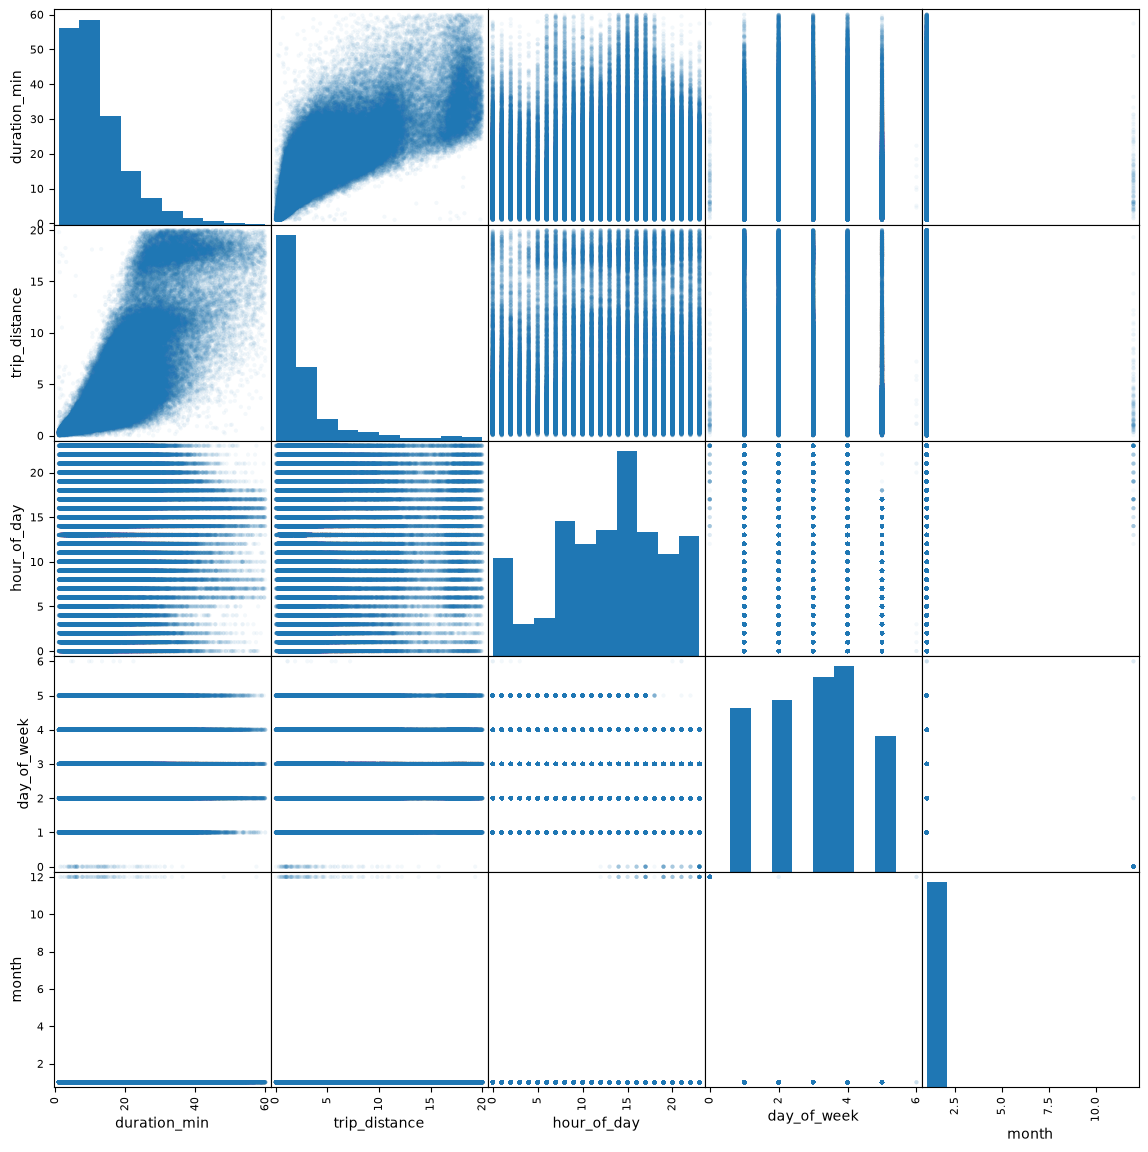

In [36]:
cols_time = [ 'duration_min','trip_distance', 'hour_of_day', 'day_of_week', 'month']

pd.plotting.scatter_matrix(df_clean[cols_time], alpha=0.05, figsize=(14, 14), diagonal='hist')
plt.show()

In [37]:
corr_time = df_clean[cols_time].corr()

px.imshow(corr_time, text_auto='.2f', color_continuous_scale='RdBu_r', zmin=-1, zmax=1,
          title='Correlation Matrix - Time Features')

Resampling - Taking every 10th row across the full dataset to avoid month bias

In [ ]:
df = pd.read_sql("SELECT * FROM tripdata WHERE rowid % 10 = 0 LIMIT 5000000", conn)

pickup = pd.to_datetime(df['tpep_pickup_datetime'])
df['duration_min'] = (pd.to_datetime(df['tpep_dropoff_datetime']) - pickup).dt.total_seconds() / 60
df['hour_of_day']  = pickup.dt.hour
df['day_of_week']  = pickup.dt.dayofweek
df['month']        = pickup.dt.month

df_clean = df[
    (df['trip_distance'].between(0.01, 20)) &
    (df['duration_min'].between(1, 60)) &
    (df['passenger_count'].between(1, 6)) &
    (df['ratecodeid'].between(1, 6))
]

cols_time = ['trip_distance', 'duration_min', 'hour_of_day', 'day_of_week', 'month']

pd.plotting.scatter_matrix(df_clean[cols_time], alpha=0.05, figsize=(14, 14), diagonal='hist')
plt.show()

^ Only one month is represented, need to collect more than just the first 5 million